In [1]:
# =========================
# SEASONALITY TEST FOR SARIMA
# Dataset: Electric_Vehicle_Charging_Station_Data.csv
# Target series: hourly count of charging sessions
# =========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# -------------------------
# 1. LOAD DATA
# -------------------------
file_path = "Electric_Vehicle_Charging_Station_Data.csv"   # same folder as your notebook/script
df = pd.read_csv(file_path)

In [3]:
# -------------------------
# 2. PARSE DATETIME COLUMN
# -------------------------
# Main time column in your dataset
time_col = "Start_Date___Time"

# Convert to datetime
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# Drop rows where datetime failed
df = df.dropna(subset=[time_col]).copy()

# Sort by time
df = df.sort_values(time_col)

In [4]:
# -------------------------
# 3. BUILD TIME SERIES
# -------------------------
# SARIMA needs a regular time series.
# Here we create HOURLY session counts.
ts = (
    df.set_index(time_col)
      .resample("H")
      .size()
      .asfreq("H", fill_value=0)
)

# If you want hourly total energy instead, use this instead:
# ts = (
#     df.set_index(time_col)["Energy__kWh_"]
#       .resample("H")
#       .sum()
#       .asfreq("H", fill_value=0)
# )

print("Time series created.")
print(f"Start: {ts.index.min()}")
print(f"End:   {ts.index.max()}")
print(f"Length: {len(ts)}")
print("\nFirst 10 values:")
print(ts.head(10))

Time series created.
Start: 2018-01-01 17:00:00
End:   2023-11-30 23:00:00
Length: 51823

First 10 values:
Start_Date___Time
2018-01-01 17:00:00    2
2018-01-01 18:00:00    0
2018-01-01 19:00:00    0
2018-01-01 20:00:00    0
2018-01-01 21:00:00    0
2018-01-01 22:00:00    0
2018-01-01 23:00:00    0
2018-01-02 00:00:00    0
2018-01-02 01:00:00    0
2018-01-02 02:00:00    0
Freq: h, dtype: int64


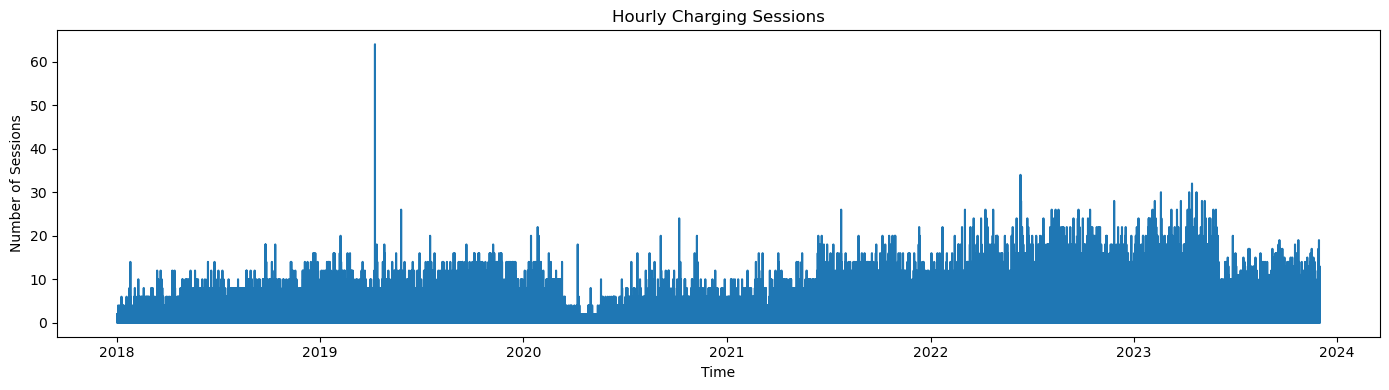

In [5]:
# -------------------------
# 4. BASIC PLOT
# -------------------------
plt.figure(figsize=(14, 4))
plt.plot(ts)
plt.title("Hourly Charging Sessions")
plt.xlabel("Time")
plt.ylabel("Number of Sessions")
plt.tight_layout()
plt.show()

In [6]:
# -------------------------
# 5. TEST SEASONALITY AT SARIMA LAGS
# -------------------------
# For hourly data:
# 24  = daily seasonality
# 168 = weekly seasonality
seasonal_lags = [24, 168]

# Compute ACF and PACF
max_lag = max(seasonal_lags)
acf_vals = acf(ts, nlags=max_lag, fft=True)
pacf_vals = pacf(ts, nlags=max_lag, method="ywm")

# Rough 95% confidence band for autocorrelation
conf_band = 1.96 / np.sqrt(len(ts))

print("\nACF/PACF values at key seasonal lags:")
rows = []
for lag in seasonal_lags:
    rows.append([lag, acf_vals[lag], pacf_vals[lag]])

results_df = pd.DataFrame(rows, columns=["lag", "ACF", "PACF"])
print(results_df.to_string(index=False))

print(f"\nApprox 95% band (rough): ±{conf_band:.6f}")

for lag in seasonal_lags:
    acf_sig = "SIGNIFICANT" if abs(acf_vals[lag]) > conf_band else "NOT significant"
    pacf_sig = "SIGNIFICANT" if abs(pacf_vals[lag]) > conf_band else "NOT significant"
    print(f"\nLag {lag}:")
    print(f"  ACF  = {acf_vals[lag]:.6f} -> {acf_sig}")
    print(f"  PACF = {pacf_vals[lag]:.6f} -> {pacf_sig}")


ACF/PACF values at key seasonal lags:
 lag      ACF     PACF
  24 0.581581 0.207471
 168 0.595354 0.128223

Approx 95% band (rough): ±0.008610

Lag 24:
  ACF  = 0.581581 -> SIGNIFICANT
  PACF = 0.207471 -> SIGNIFICANT

Lag 168:
  ACF  = 0.595354 -> SIGNIFICANT
  PACF = 0.128223 -> SIGNIFICANT


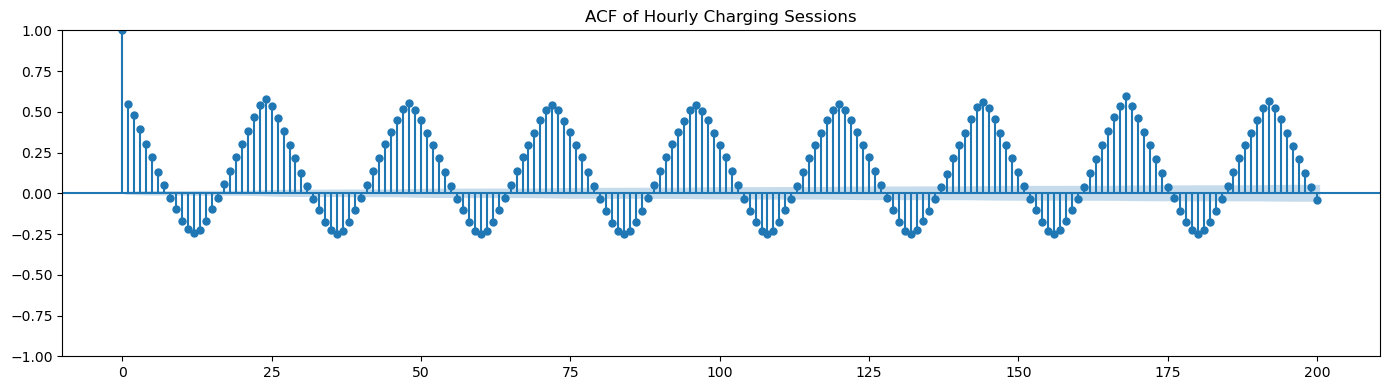

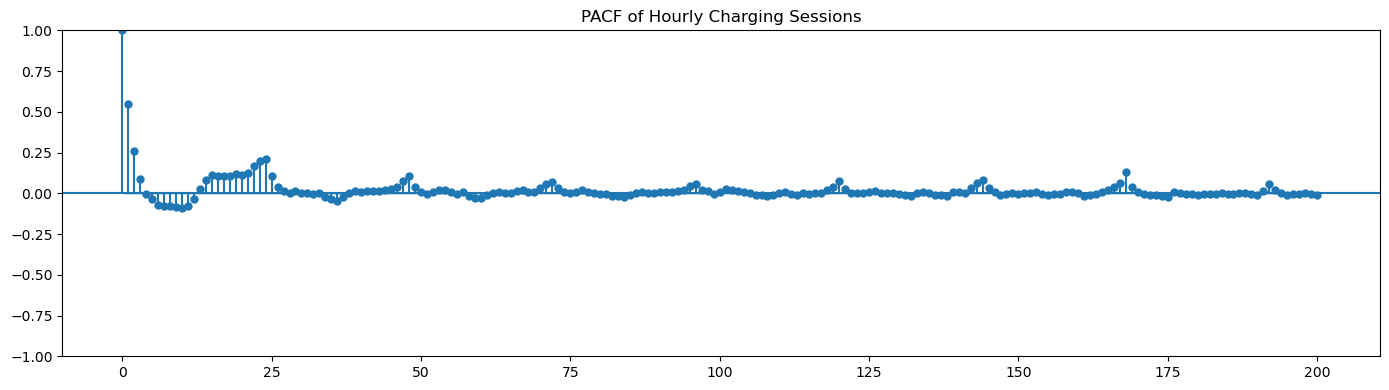

In [7]:
# -------------------------
# 6. FULL ACF/PACF PLOTS
# -------------------------
plt.figure(figsize=(14, 4))
plot_acf(ts, lags=200, ax=plt.gca())
plt.title("ACF of Hourly Charging Sessions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plot_pacf(ts, lags=200, ax=plt.gca(), method="ywm")
plt.title("PACF of Hourly Charging Sessions")
plt.tight_layout()
plt.show()

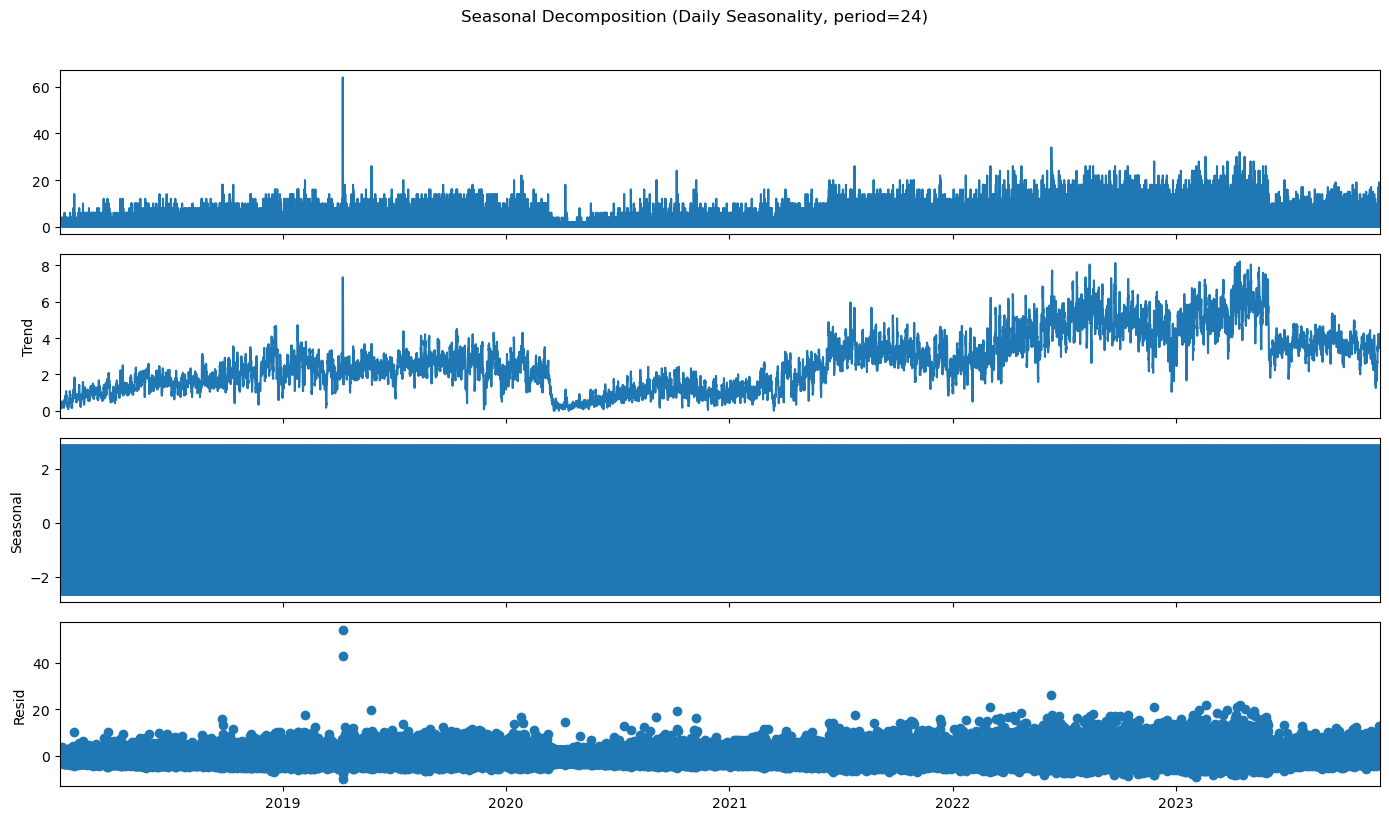

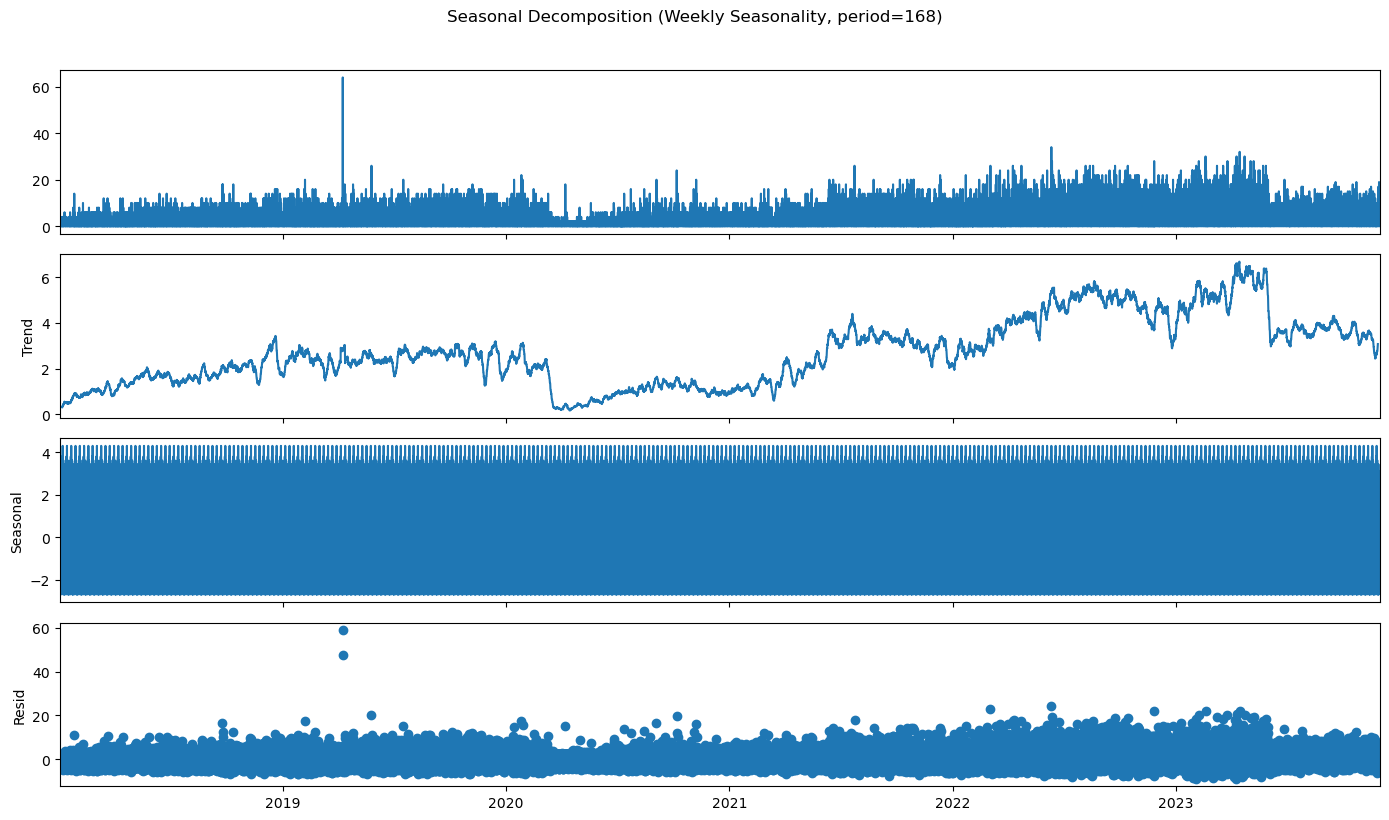

In [8]:
# -------------------------
# 7. SEASONAL DECOMPOSITION
# -------------------------
# Check daily seasonality
decomp_daily = seasonal_decompose(ts, model="additive", period=24)
fig = decomp_daily.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Seasonal Decomposition (Daily Seasonality, period=24)", y=1.02)
plt.tight_layout()
plt.show()

# Check weekly seasonality
decomp_weekly = seasonal_decompose(ts, model="additive", period=168)
fig = decomp_weekly.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Seasonal Decomposition (Weekly Seasonality, period=168)", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# -------------------------
# 8. SEASONAL STRENGTH
# -------------------------
# Strength formula:
# Fs = max(0, 1 - var(remainder) / var(seasonal + remainder))
def seasonal_strength(decomp_result):
    seasonal = decomp_result.seasonal.dropna()
    resid = decomp_result.resid.dropna()
    common_idx = seasonal.index.intersection(resid.index)
    seasonal = seasonal.loc[common_idx]
    resid = resid.loc[common_idx]
    return max(0, 1 - np.var(resid) / np.var(seasonal + resid))

strength_daily = seasonal_strength(decomp_daily)
strength_weekly = seasonal_strength(decomp_weekly)

print("\nSeasonal strength:")
print(f"Daily  (24):  {strength_daily:.4f}")
print(f"Weekly (168): {strength_weekly:.4f}")

# Rule of thumb:
# > 0.6  = strong seasonality
# 0.3-0.6 = moderate seasonality
# < 0.3  = weak seasonality


Seasonal strength:
Daily  (24):  0.3863
Weekly (168): 0.3990



Seasonal differencing check for s=24
Original variance: 14.7108
Differenced variance: 12.3077


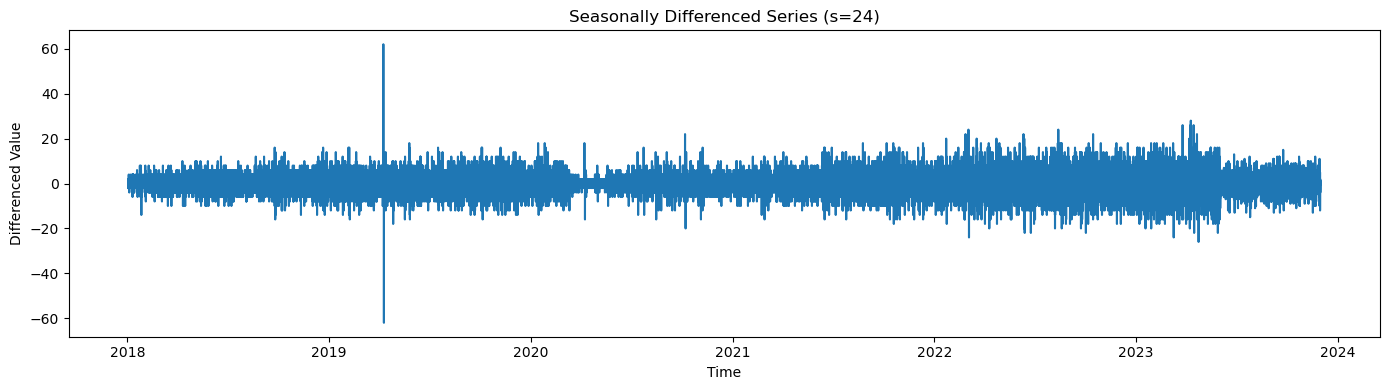


Seasonal differencing check for s=168
Original variance: 14.7108
Differenced variance: 11.8809


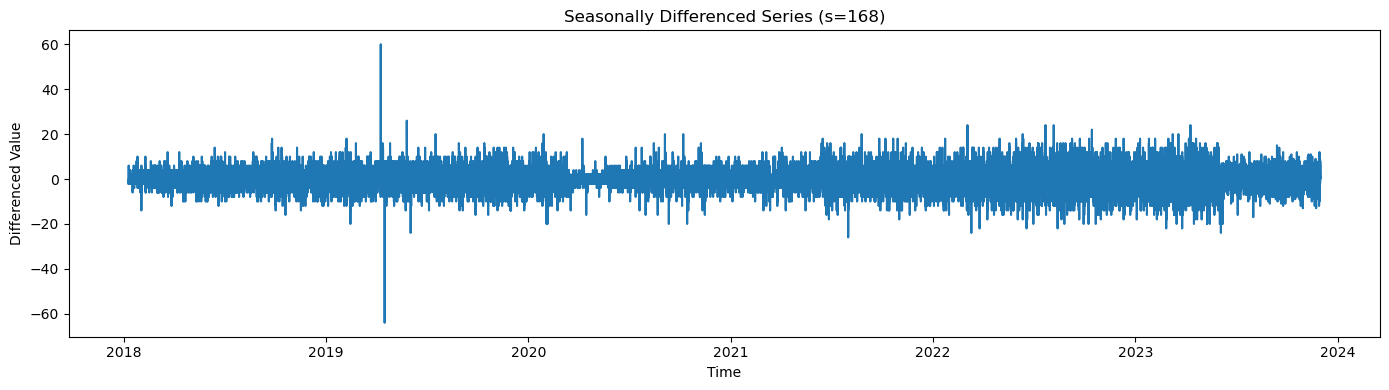

In [10]:
# -------------------------
# 9. OPTIONAL: COMPARE VARIANCE BEFORE/AFTER SEASONAL DIFFERENCING
# -------------------------
# If seasonal differencing reduces structure and stabilizes the series,
# that supports the presence of seasonality.
def seasonal_difference(series, s):
    return series.diff(s).dropna()

for s in seasonal_lags:
    diff_ts = seasonal_difference(ts, s)

    print(f"\nSeasonal differencing check for s={s}")
    print(f"Original variance: {np.var(ts):.4f}")
    print(f"Differenced variance: {np.var(diff_ts):.4f}")

    plt.figure(figsize=(14, 4))
    plt.plot(diff_ts)
    plt.title(f"Seasonally Differenced Series (s={s})")
    plt.xlabel("Time")
    plt.ylabel("Differenced Value")
    plt.tight_layout()
    plt.show()

In [11]:
# -------------------------
# 10. FINAL INTERPRETATION
# -------------------------
print("\nINTERPRETATION GUIDE")
print("- If ACF has strong spikes at lag 24 and/or 168, seasonality is present.")
print("- If decomposition shows a repeating pattern, seasonality is present.")
print("- If seasonal strength is high (>0.6), seasonality is strong.")
print("- For SARIMA:")
print("    Use seasonal_period=24 if daily pattern is stronger.")
print("    Use seasonal_period=168 if weekly pattern is stronger.")
print("    Seasonal order is (P, D, Q, s).")


INTERPRETATION GUIDE
- If ACF has strong spikes at lag 24 and/or 168, seasonality is present.
- If decomposition shows a repeating pattern, seasonality is present.
- If seasonal strength is high (>0.6), seasonality is strong.
- For SARIMA:
    Use seasonal_period=24 if daily pattern is stronger.
    Use seasonal_period=168 if weekly pattern is stronger.
    Seasonal order is (P, D, Q, s).
